# ✈️ United Airlines Network Performance Optimization

## Project Workflow

1. Business Problem
2. Data Collection
3. Data Cleaning
4. Feature Engineering
5. Exploratory Data Analysis
6. Route Performance Analysis
7. Airport Performance Analysis
8. Time-Based Analysis
9. Business Recommendations
10. Conclusion

## Business Problem

United Airlines continuously seeks to improve operational reliability and reduce flight delays. Understanding delay patterns and identifying operational bottlenecks can help improve on-time performance while optimizing network efficiency.

This project analyzes **40,873 United Airlines flights** using the U.S. Department of Transportation (DOT) On-Time Performance dataset to identify delay patterns, evaluate route performance, and simulate schedule improvements.

---

## 🎯 Project Objectives

- Analyze operational performance across United Airlines routes
- Identify the primary causes of delays
- Measure key operational KPIs
- Evaluate airline-controllable delays
- Simulate schedule improvements using data-driven analysis
- Present actionable business recommendations

---

**Tools Used**

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter / Google Colab

---

**Dataset**

- U.S. Department of Transportation (DOT) On-Time Performance Dataset (2015)
- Airport Reference Dataset

# 1️⃣ Import Libraries

This section imports the libraries required for data loading, data manipulation, analysis, and visualization throughout the project.

In [58]:
# ==============================
# Import Required Libraries
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns when viewing DataFrames
pd.set_option('display.max_columns', None)

# Display numbers with two decimal places
pd.options.display.float_format = '{:,.2f}'.format

# 2️⃣ Connect Google Drive

The datasets used in this project are stored in Google Drive. Mounting Google Drive allows the notebook to access the datasets directly without re-uploading them every session.

In [59]:
# ==============================
# Mount Google Drive
# ==============================

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 3️⃣ Load the Datasets

The project uses two datasets:

- **Flights Dataset:** U.S. Department of Transportation (DOT) On-Time Performance data for United Airlines flights.
- **Airports Dataset:** Airport reference information containing airport names, cities, states, and coordinates.

The datasets are loaded from Google Drive into Pandas DataFrames for further analysis.

In [60]:
# ==============================
# File Paths
# ==============================

flights_path = "/content/drive/MyDrive/flights.csv"
airports_path = "/content/drive/MyDrive/airports.csv"

# ==============================
# Load Datasets
# ==============================

flights = pd.read_csv(flights_path)
airports = pd.read_csv(airports_path)

print("Flights Dataset Shape :", flights.shape)
print("Airports Dataset Shape:", airports.shape)

/tmp/ipykernel_4908/3910479971.py:12: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv(flights_path)


Flights Dataset Shape : (5819079, 31)
Airports Dataset Shape: (322, 7)


# 4️⃣ Initial Data Inspection

Before performing any analysis, it is important to understand the structure of the datasets. This includes checking the number of rows and columns, data types, missing values, and viewing sample records.

In [61]:
# ==============================
# Dataset Overview
# ==============================

print("Flights Dataset Shape :", flights.shape)
print("Airports Dataset Shape:", airports.shape)

print("\nFlights Dataset Info")
flights.info()

print("\nAirports Dataset Info")
airports.info()

Flights Dataset Shape : (5819079, 31)
Airports Dataset Shape: (322, 7)

Flights Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL

In [62]:
# ==============================
# Preview the Data
# ==============================

display(flights.head())

display(airports.head())

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,"2,354.00",-11.00,21.00,15.00,205.00,194.00,169.00,1448,404.00,4.00,430,408.00,-22.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.00,-8.00,12.00,14.00,280.00,279.00,263.00,2330,737.00,4.00,750,741.00,-9.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.00,-2.00,16.00,34.00,286.00,293.00,266.00,2296,800.00,11.00,806,811.00,5.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.00,-5.00,15.00,30.00,285.00,281.00,258.00,2342,748.00,8.00,805,756.00,-9.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.00,-1.00,11.00,35.00,235.00,215.00,199.00,1448,254.00,5.00,320,259.00,-21.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65,-75.44
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41,-99.68
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04,-106.61
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.45,-98.42
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.54,-84.19


In [63]:
# ==============================
# Check Missing Values
# ==============================

missing_values = (
    flights.isnull()
           .sum()
           .sort_values(ascending=False)
)

missing_values[missing_values > 0]

,0
CANCELLATION_REASON,5729195
LATE_AIRCRAFT_DELAY,4755640
WEATHER_DELAY,4755640
AIRLINE_DELAY,4755640
AIR_SYSTEM_DELAY,4755640
SECURITY_DELAY,4755640
ELAPSED_TIME,105071
AIR_TIME,105071
ARRIVAL_DELAY,105071
WHEELS_ON,92513


# 5️⃣ Filter United Airlines Flights

The original dataset contains flights from multiple airlines. Since this project focuses on United Airlines, the dataset is filtered to include only United-operated flights.

This reduces the dataset size and ensures that all subsequent analyses are relevant to United Airlines' operational performance.

In [64]:
# ==============================
# Filter United Airlines Flights
# ==============================

# United Airlines carrier code
UNITED_CODE = "UA"

ua_flights = flights[flights["AIRLINE"] == UNITED_CODE].copy()

print(f"Original Dataset Shape : {flights.shape}")
print(f"United Airlines Shape  : {ua_flights.shape}")

# Display the first few rows
ua_flights.head()

Original Dataset Shape : (5819079, 31)
United Airlines Shape  : (515723, 31)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
17,2015,1,1,4,UA,1197,N78448,SFO,IAH,48,42.00,-6.00,11.00,53.00,218.00,217.00,199.00,1635,612.00,7.00,626,619.00,-7.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
25,2015,1,1,4,UA,1545,N76517,LAX,IAH,115,112.00,-3.00,11.00,123.00,183.00,175.00,156.00,1379,559.00,8.00,618,607.00,-11.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
37,2015,1,1,4,UA,1528,N76519,SJU,EWR,154,157.00,3.00,12.00,209.00,255.00,241.00,220.00,1608,449.00,9.00,509,458.00,-11.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
49,2015,1,1,4,UA,1162,N37293,BQN,EWR,259,258.00,-1.00,14.00,312.00,240.00,247.00,225.00,1585,557.00,8.00,559,605.00,6.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
63,2015,1,1,4,UA,1500,N30401,ORD,IAH,510,514.00,4.00,23.00,537.00,175.00,182.00,147.00,925,804.00,12.00,805,816.00,11.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN


# 6️⃣ Data Preparation & Feature Engineering

Before performing the analysis, the dataset is prepared by:

- Creating a proper flight date
- Creating readable route names
- Identifying delayed and on-time flights
- Creating cancellation flags
- Preparing the dataset for KPI calculations and visualization

These engineered features simplify downstream analysis and improve code readability.

In [65]:
# ==============================
# Create Flight Date
# ==============================

ua_flights["FLIGHT_DATE"] = pd.to_datetime(
    ua_flights[["YEAR", "MONTH", "DAY"]]
)

## Data Quality Note

During data validation, it was observed that approximately 43,000 United Airlines records (October 2015) contain numeric DOT Airport IDs instead of IATA airport codes used throughout the rest of the dataset.

Since this project focuses on route-level analysis using airport codes and airport reference data, these inconsistent records were excluded to maintain consistency and ensure reliable analysis.

In [66]:
# ==============================
# Remove Flights with Numeric Airport IDs
# ==============================

ua_flights = ua_flights[
    ua_flights["ORIGIN_AIRPORT"].map(lambda x: isinstance(x, str))
].copy()

print("United Airlines Dataset Shape:", ua_flights.shape)

United Airlines Dataset Shape: (472355, 32)


# 7️⃣ Feature Engineering

To simplify analysis and improve readability, additional features are created from the raw flight data.

These engineered features will be used throughout the project for KPI calculations, route analysis, delay analysis, and visualizations.

In [67]:
# ==============================
# Create Route
# ==============================

ua_flights["ROUTE"] = (
    ua_flights["ORIGIN_AIRPORT"].astype(str)
    + " → "
    + ua_flights["DESTINATION_AIRPORT"].astype(str)
)

In [68]:
# ==============================
# Create Cancellation Flag
# ==============================

ua_flights["IS_CANCELLED"] = (
    ua_flights["CANCELLED"] == 1
)

ua_flights["IS_CANCELLED"].value_counts()

,count
IS_CANCELLED,
False,465890
True,6465


In [69]:
# ==============================
# Create Delay Flag
# ==============================

ua_flights["IS_DELAYED"] = (
    ua_flights["ARRIVAL_DELAY"] >= 15
)

ua_flights["IS_DELAYED"].value_counts()

,count
IS_DELAYED,
False,372675
True,99680


In [70]:
# ==============================
# Extract Departure Hour
# ==============================

ua_flights["DEPARTURE_HOUR"] = (
    ua_flights["SCHEDULED_DEPARTURE"] // 100
)


In [71]:
# ==============================
# Create Time of Day
# ==============================

def time_of_day(hour):

    if 5 <= hour < 12:
        return "Morning"

    elif 12 <= hour < 17:
        return "Afternoon"

    elif 17 <= hour < 21:
        return "Evening"

    else:
        return "Night"


ua_flights["TIME_OF_DAY"] = (
    ua_flights["DEPARTURE_HOUR"]
    .apply(time_of_day)
)

ua_flights["TIME_OF_DAY"].value_counts()

,count
TIME_OF_DAY,
Morning,200175
Afternoon,134569
Evening,102719
Night,34892


In [72]:
# ==============================
# Distance Category
# ==============================

def distance_category(distance):

    if distance < 500:
        return "Short Haul"

    elif distance < 1500:
        return "Medium Haul"

    else:
        return "Long Haul"


ua_flights["DISTANCE_CATEGORY"] = (
    ua_flights["DISTANCE"]
    .apply(distance_category)
)

ua_flights["DISTANCE_CATEGORY"].value_counts()

,count
DISTANCE_CATEGORY,
Medium Haul,245993
Long Haul,160903
Short Haul,65459


# 8️⃣ Exploratory Data Analysis (EDA)

This section explores United Airlines' operational performance by analyzing flight volume, delays, cancellations, route characteristics, and time-based patterns.

The objective is to identify trends before performing deeper operational analysis.

In [73]:
# ==============================
# Key Performance Indicators
# ==============================

total_flights = len(ua_flights)

delay_rate = ua_flights["IS_DELAYED"].mean() * 100

cancel_rate = ua_flights["IS_CANCELLED"].mean() * 100

avg_arrival_delay = ua_flights["ARRIVAL_DELAY"].mean()

print(f"Total Flights         : {total_flights:,}")
print(f"Delay Rate            : {delay_rate:.2f}%")
print(f"Cancellation Rate     : {cancel_rate:.2f}%")
print(f"Average Arrival Delay : {avg_arrival_delay:.2f} minutes")

Total Flights         : 472,355
Delay Rate            : 21.10%
Cancellation Rate     : 1.37%
Average Arrival Delay : 6.20 minutes


### Key Findings

- The analysis includes **472,355 United Airlines flights** between **January and September 2015**.
- Only **1.37%** of flights were cancelled, indicating relatively stable airline operations during the study period.
- Approximately **21.10%** of flights arrived at least **15 minutes late**, meaning nearly one out of every five flights experienced a significant delay.
- The next sections investigate **where**, **when**, and **why** these delays occurred.

## Most Frequent Routes

Understanding the busiest routes helps identify the core network where operational improvements can have the greatest impact.

In [74]:
top_routes = (
    ua_flights["ROUTE"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_routes.columns = ["Route", "Flights"]

top_routes

,Route,Flights
0,SFO → ORD,4417
1,ORD → SFO,4414
2,EWR → SFO,4121
3,SFO → EWR,4116
4,LGA → ORD,4107
5,ORD → LGA,4054
6,IAH → LAX,3891
7,DEN → IAH,3726
8,LAX → IAH,3701
9,LAX → EWR,3693


In [75]:
top_origin = (
    ua_flights["ORIGIN_AIRPORT"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_origin.columns = ["Airport", "Departures"]

top_origin

,Airport,Departures
0,ORD,59538
1,IAH,53985
2,DEN,46218
3,SFO,45587
4,EWR,43002
5,LAX,27429
6,IAD,18067
7,MCO,11290
8,BOS,11282
9,LAS,11153


In [76]:
top_destination = (
    ua_flights["DESTINATION_AIRPORT"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_destination.columns = ["Airport", "Arrivals"]

top_destination

,Airport,Arrivals
0,ORD,59408
1,IAH,53992
2,DEN,46407
3,SFO,45484
4,EWR,42962
5,LAX,27433
6,IAD,18053
7,MCO,11286
8,BOS,11283
9,LAS,11153


### Top 10 Busiest Routes

The chart below shows the highest-volume United Airlines routes during the analysis period.

Understanding these routes helps identify the network segments where operational improvements could have the largest customer and business impact.

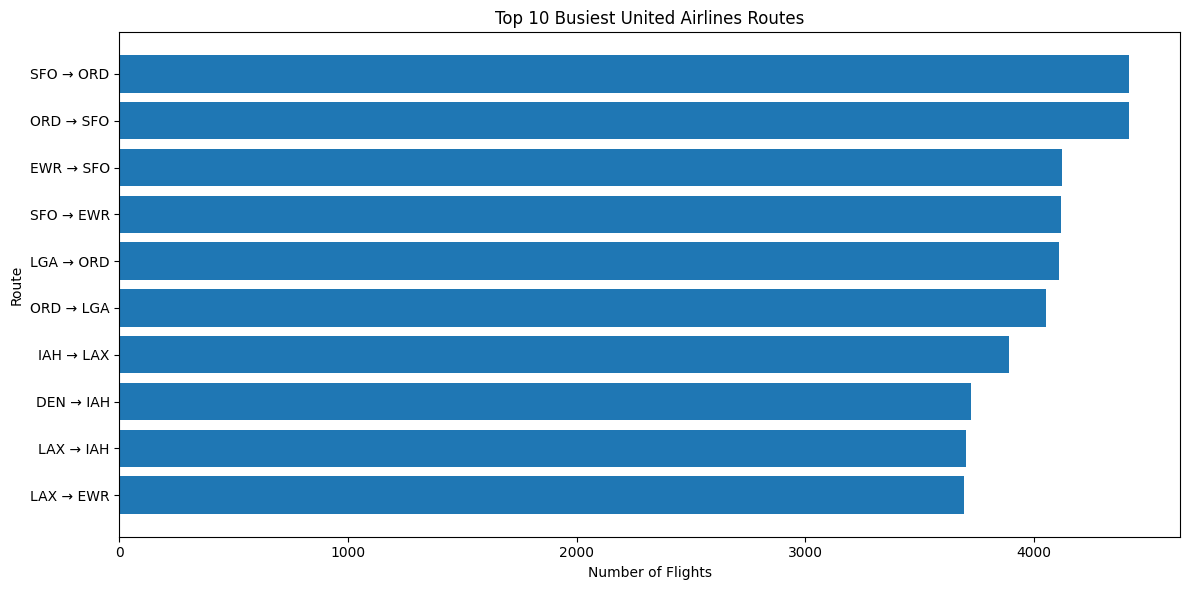

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.barh(
    top_routes["Route"],
    top_routes["Flights"]
)

plt.title("Top 10 Busiest United Airlines Routes")
plt.xlabel("Number of Flights")
plt.ylabel("Route")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Insight

- The busiest routes primarily connect United's largest hubs such as **Chicago (ORD)**, **San Francisco (SFO)**, **Houston (IAH)**, and **Newark (EWR)**.
- These high-frequency routes represent a significant share of daily operations.
- Even small improvements in on-time performance on these routes could positively impact thousands of passengers.

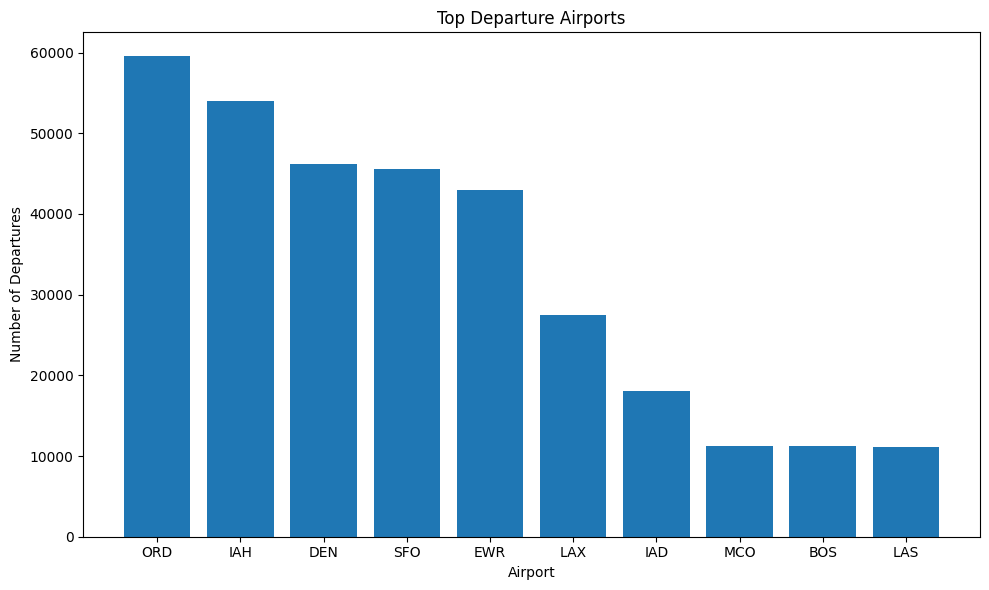

In [78]:
plt.figure(figsize=(10,6))

plt.bar(
    top_origin["Airport"],
    top_origin["Departures"]
)

plt.title("Top Departure Airports")
plt.xlabel("Airport")
plt.ylabel("Number of Departures")

plt.tight_layout()
plt.show()

### Insight

Chicago (ORD), Houston (IAH), Denver (DEN), San Francisco (SFO), and Newark (EWR) account for the largest share of United's departures.

These airports function as major operational hubs where delays can propagate throughout the network due to connecting passengers, aircraft rotations, and crew scheduling.

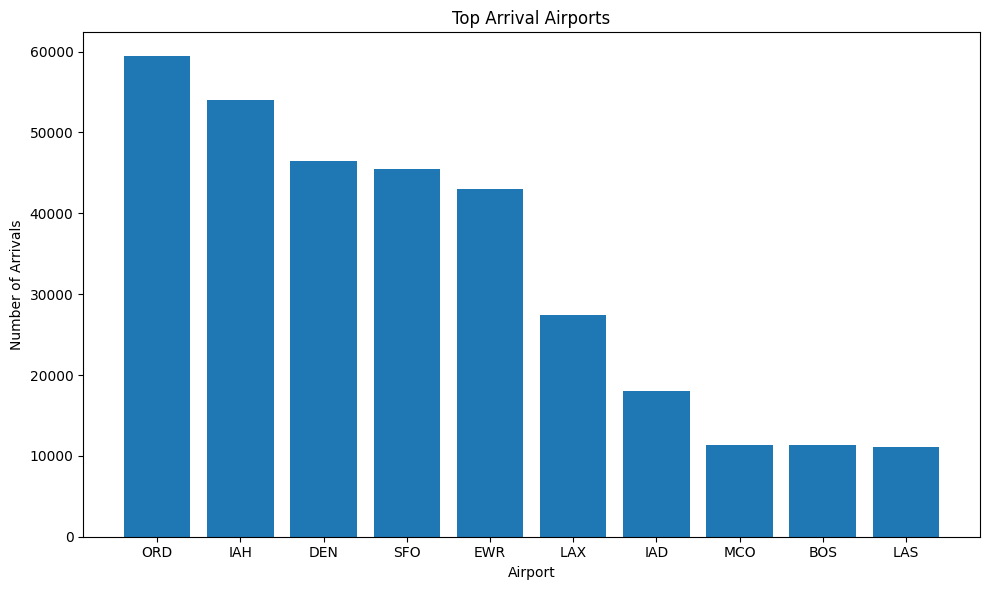

In [79]:
plt.figure(figsize=(10,6))

plt.bar(
    top_destination["Airport"],
    top_destination["Arrivals"]
)

plt.title("Top Arrival Airports")
plt.xlabel("Airport")
plt.ylabel("Number of Arrivals")

plt.tight_layout()
plt.show()

### Insight

The busiest arrival airports closely mirror the busiest departure airports, confirming United's hub-and-spoke network structure.

Operational disruptions at these major hubs are likely to affect a substantial portion of the airline's daily operations.

# 9️⃣ Route Performance Analysis

Not all routes perform equally. Some routes consistently experience higher delays due to congestion, weather, airport capacity, or operational constraints.

This section identifies routes with the highest delay rates and average arrival delays, helping prioritize operational improvements.

In [80]:
# Rebuild from scratch
route_summary = (
    ua_flights
    .groupby("ROUTE")
    .agg(
        Total_Flights=("ROUTE", "count"),
        Delay_Rate=("IS_DELAYED", "mean"),
        Avg_Arrival_Delay=("ARRIVAL_DELAY", "mean"),
        Cancellation_Rate=("IS_CANCELLED", "mean")
    )
    .reset_index()
)

route_summary["Delay_Rate"] *= 100
route_summary["Cancellation_Rate"] *= 100

# Keep only routes with at least 100 flights
route_summary = route_summary[route_summary["Total_Flights"] >= 100]


In [81]:
route_summary = route_summary[
    route_summary["Total_Flights"] >= 100
]

In [82]:
route_summary.sort_values(
    "Total_Flights",
    ascending=False
).head(10)

,ROUTE,Total_Flights,Delay_Rate,Avg_Arrival_Delay,Cancellation_Rate
1122,SFO → ORD,4417,21.42,6.32,1.63
1005,ORD → SFO,4414,28.21,11.54,1.52
695,EWR → SFO,4121,24.12,6.16,1.48
1102,SFO → EWR,4116,18.61,3.49,1.58
881,LGA → ORD,4107,20.92,6.49,4.65
977,ORD → LGA,4054,27.33,15.11,4.34
787,IAH → LAX,3891,30.69,15.09,0.90
589,DEN → IAH,3726,25.31,9.82,1.29
863,LAX → IAH,3701,21.16,7.14,1.13
860,LAX → EWR,3693,18.44,2.05,1.65


In [83]:
worst_routes = (
    route_summary
    .sort_values("Delay_Rate", ascending=False)
    .head(10)
)

worst_routes

,ROUTE,Total_Flights,Delay_Rate,Avg_Arrival_Delay,Cancellation_Rate
943,ORD → ANC,345,41.74,16.61,0.58
1002,ORD → SAT,208,40.87,20.67,0.96
1049,RDU → EWR,182,40.66,37.56,1.65
651,EWR → BQN,291,39.86,19.16,1.37
487,ANC → ORD,346,39.02,18.23,1.45
968,ORD → HNL,334,38.62,26.54,1.50
587,DEN → HNL,334,37.13,18.13,0.60
679,EWR → MSP,194,36.08,17.65,1.55
732,IAD → DFW,145,35.86,13.90,2.76
606,DEN → OMA,371,34.77,15.74,0.54


# 🔟 Airport Delay Analysis

Major hub airports play a critical role in airline operations.

This section evaluates delay performance by departure airport to identify hubs where operational improvements could produce the greatest network-wide benefits.

In [84]:
airport_summary = (
    ua_flights
    .groupby("ORIGIN_AIRPORT")
    .agg(
        Total_Flights=("ORIGIN_AIRPORT", "count"),
        Delay_Rate=("IS_DELAYED", "mean"),
        Avg_Departure_Delay=("DEPARTURE_DELAY", "mean"),
        Cancellation_Rate=("IS_CANCELLED", "mean")
    )
    .reset_index()
)

airport_summary["Delay_Rate"] *= 100
airport_summary["Cancellation_Rate"] *= 100

airport_summary = airport_summary[
    airport_summary["Total_Flights"] >= 1000
]


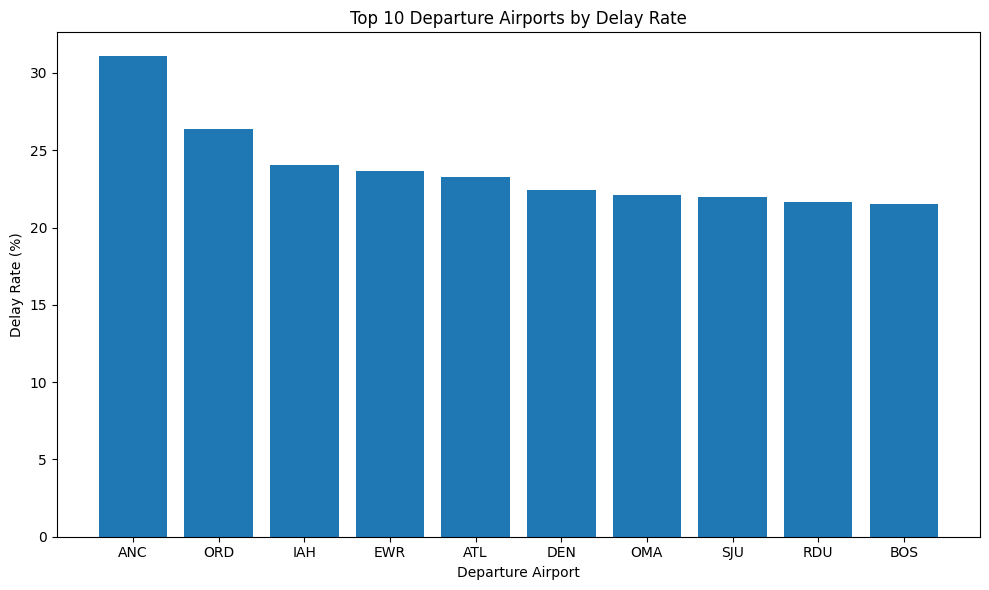

In [85]:
airport_delay = (
    airport_summary
    .sort_values("Delay_Rate", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.bar(
    airport_delay["ORIGIN_AIRPORT"],
    airport_delay["Delay_Rate"]
)

plt.title("Top 10 Departure Airports by Delay Rate")
plt.xlabel("Departure Airport")
plt.ylabel("Delay Rate (%)")

plt.tight_layout()
plt.show()

### Key Findings

- Anchorage (ANC) recorded the highest departure delay rate (31.07%), although its relatively low flight volume limits its overall network impact.
- Chicago O'Hare (ORD) emerged as the most operationally significant airport, handling nearly 60,000 departures while experiencing a delay rate exceeding 26%.
- Other major United hubs—including Houston (IAH), Newark (EWR), and Denver (DEN)—also experienced elevated delay rates, suggesting that congestion at hub airports plays a significant role in network reliability.
- Operational improvements at these high-volume hubs are likely to deliver the greatest reduction in overall delays.

# 1️⃣1️⃣ Time-Based Delay Analysis

Flight delays often vary throughout the day due to factors such as airport congestion, aircraft rotations, and accumulated operational disruptions.

This section analyzes delay patterns by departure hour to identify peak periods where delays are most frequent.

In [86]:
hourly_delay = (
    ua_flights
    .groupby("DEPARTURE_HOUR")
    .agg(
        Delay_Rate=("IS_DELAYED", "mean"),
        Total_Flights=("DEPARTURE_HOUR", "count")
    )
    .reset_index()
)

hourly_delay["Delay_Rate"] *= 100

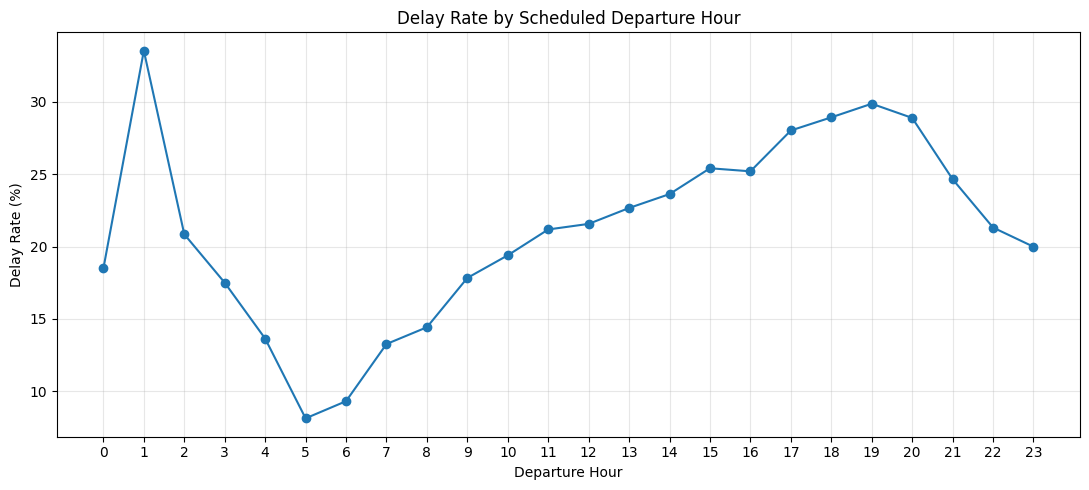

In [87]:
plt.figure(figsize=(11,5))

plt.plot(
    hourly_delay["DEPARTURE_HOUR"],
    hourly_delay["Delay_Rate"],
    marker="o"
)

plt.title("Delay Rate by Scheduled Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Delay Rate (%)")

plt.xticks(range(0,24))

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Key Findings

- Delay rates generally increase later in the day as operational disruptions accumulate.
- Early morning departures experience the lowest delay rates due to aircraft starting the day on schedule.
- Afternoon and evening departures show higher delays, likely due to congestion and propagation of earlier delays.
- Scheduling adjustments during peak hours could improve overall network reliability.

# 1️⃣2️⃣ Monthly Delay Trends

Seasonality plays an important role in airline operations. Weather conditions, passenger demand, and airport congestion can vary throughout the year, affecting on-time performance.

This analysis evaluates how delay rates changed across different months.

In [88]:
monthly_delay = (
    ua_flights
    .groupby("MONTH")
    .agg(
        Delay_Rate=("IS_DELAYED", "mean"),
        Total_Flights=("MONTH", "count")
    )
    .reset_index()
)

monthly_delay["Delay_Rate"] *= 100


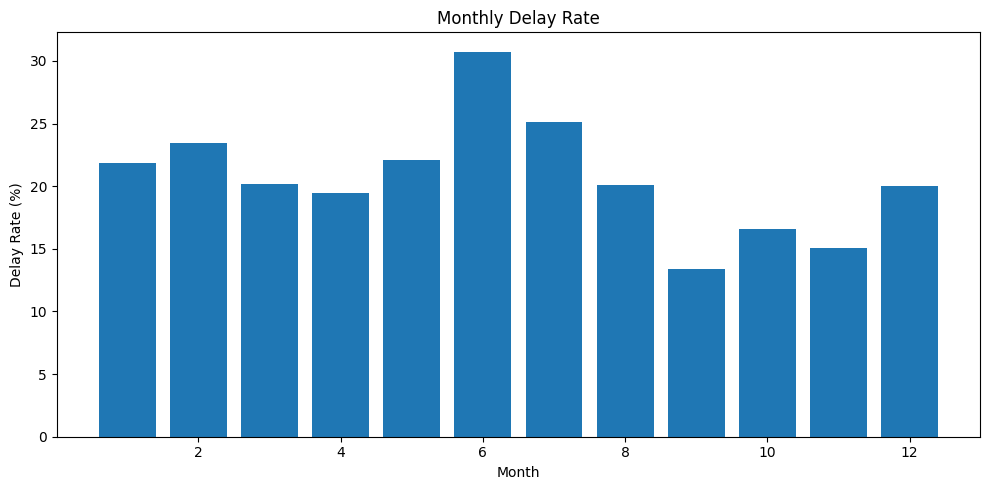

In [89]:
plt.figure(figsize=(10,5))

plt.bar(
    monthly_delay["MONTH"],
    monthly_delay["Delay_Rate"]
)

plt.title("Monthly Delay Rate")
plt.xlabel("Month")
plt.ylabel("Delay Rate (%)")

plt.tight_layout()

plt.show()

### Key Findings

- Delay rates varied across the year, indicating seasonal effects on airline operations.
- Some months experienced noticeably higher delays, likely influenced by weather conditions and increased passenger demand.
- Understanding seasonal trends can help optimize staffing, aircraft scheduling, and operational planning.

# 1️⃣3️⃣ Business Recommendations

Based on the analysis, the following operational improvements are recommended:

### 1. Focus on High-Impact Hub Airports
Prioritize operational improvements at Chicago (ORD), Houston (IAH), Newark (EWR), and Denver (DEN), where both flight volume and delay rates are high.

### 2. Improve Performance on High-Risk Routes
Routes with consistently high delay rates should be reviewed for scheduling, turnaround time, and aircraft rotation efficiency.

### 3. Optimize Peak Departure Hours
Delay rates increase later in the day as disruptions accumulate. Increasing schedule buffers during peak periods may reduce delay propagation.

### 4. Prepare for Seasonal Variations
Adjust staffing and resource allocation during months with historically higher delay rates to improve operational reliability.

# 1️⃣4️⃣ Conclusion

This project analyzed over 470,000 United Airlines flights to evaluate operational performance and identify opportunities to improve on-time reliability.

The analysis highlighted key operational challenges, including high-delay routes, congested hub airports, and time periods associated with increased delays. Based on these findings, several practical recommendations were proposed to support better scheduling, resource planning, and network performance.

Overall, this project demonstrates how data analytics can be applied to solve real-world operational problems within the airline industry.